# 📊 Proyecto: Análisis Comercial Inmobiliario

El sector inmobiliario necesita evaluar su **desempeño comercial** para comprender su crecimiento, rentabilidad y comportamiento de clientes.

Se solicita construir un **dashboard ejecutivo** que permita analizar ventas, clientes y propiedades para apoyar decisiones estratégicas basadas en datos.


# 📂 Descripción de los Datasets

🔹 **hecho_ventas_propiedades**  
Tabla de hechos con las transacciones de venta (precio, cliente, propiedad, canal, fecha).

🔹 **dim_clientes**  
Información y segmentación de clientes.

🔹 **dim_propiedades**  
Características de las propiedades (tipo, tamaño, ubicación, etc).

🔹 **dim_fecha**  
Tabla calendario que deberá ser creada como parte del modelado.

# 🎯 Preguntas que el dashboard debe responder

**Desempeño general**

- ¿Cuál es el **ingreso total** generado por la empresa?
- ¿Cuántas **propiedades se han vendido**?
- ¿Cuál es el **precio promedio de venta**?
- ¿Cuál es la **comisión total** generada por la empresa?

**Análisis comercial**

- ¿Qué **tipo de propiedad genera más ingresos**?
- ¿Qué **segmento de clientes compra más propiedades**?
- ¿Qué canal de venta **genera mayor ingresos**?


**Análisis temporal**

- ¿Cómo evolucionan las **ventas en el tiempo**?
- ¿El negocio está **creciendo año contra año**?
- ¿Cómo va el desempeño **acumulado del año actual (YTD)**?

**Cohortes de clientes**

- ¿Los clientes **vuelven a comprar** después de su primera compra?
- ¿Qué **cohortes de clientes generan más compras/ingresos con el tiempo**?

## 🧹 Paso 1: Limpieza de datos

Antes del modelado, debes validar y depurar la información.

### Tipos de datos

- `fecha_venta` debe estar en formato **Date**.
- Los campos numéricos deben estar correctamente formateados.
- `porcentaje_comision` debe estar en formato **porcentaje**.

### Valores nulos

- Revisar valores **nulos** en las tablas.
- Justificar si deben eliminarse o mantenerse.

### Duplicados

- Validar que no existan duplicados en las claves primarias de:
  - `dim_clientes`
  - `dim_propiedades`

## 📅 Paso 2: Creación de tabla calendario

Si vas a realizar el dashboard en **Power BI**, deberás crear una tabla calendario llamada **dim_fecha**.

**Requisitos (solo para Power BI):**

- Utilizar las funciones `CALENDAR` y `ADDCOLUMNS`.
- El rango de fechas debe construirse dinámicamente desde la **fecha mínima** hasta la **fecha máxima** de ventas en `hecho_ventas_propiedades`.
- Incluir como mínimo las siguientes columnas:
  - Año
  - Mes (nombre)
  - Número de mes
  - Año-Mes (formato `YYYY-MM`)

> ⚠️ **Nota:**  
> Si utilizas **Tableau**, no necesitas crear esta tabla. Puedes usar directamente el campo `fecha_venta` de la tabla `hecho_ventas_propiedades`, ya que Tableau genera automáticamente las jerarquías de fecha.

## 🧩 Paso 3: Modelado de datos

### Modelo requerido: Esquema estrella

El modelo debe estructurarse en formato estrella:

- `hecho_ventas_propiedades` como tabla central.
- Tablas dimensionales conectadas:
  - `dim_clientes`
  - `dim_propiedades`
  - `dim_fecha` (creada por ti, en caso de que aplique)

Requisitos de las relaciones:

- Cardinalidad **uno a muchos (1:*)**
- Dirección de filtro **simple (single)**
- Relaciones basadas en las claves correctas
- Todas las relaciones deben estar **activas**


### Modelo de datos implementado

Se implementó un modelo dimensional tipo estrella, utilizando `hecho_ventas_propiedades` como tabla central de hechos y las dimensiones `dim_clientes`, `dim_propiedades` y `dim_fecha`.

Las relaciones presentan cardinalidad **1:\*** desde las dimensiones hacia la tabla de hechos, con filtrado unidireccional y relaciones activas.

Adicionalmente, se creó una tabla independiente `Medidas` para centralizar las métricas DAX utilizadas en el dashboard.

#### Evidencia del modelo

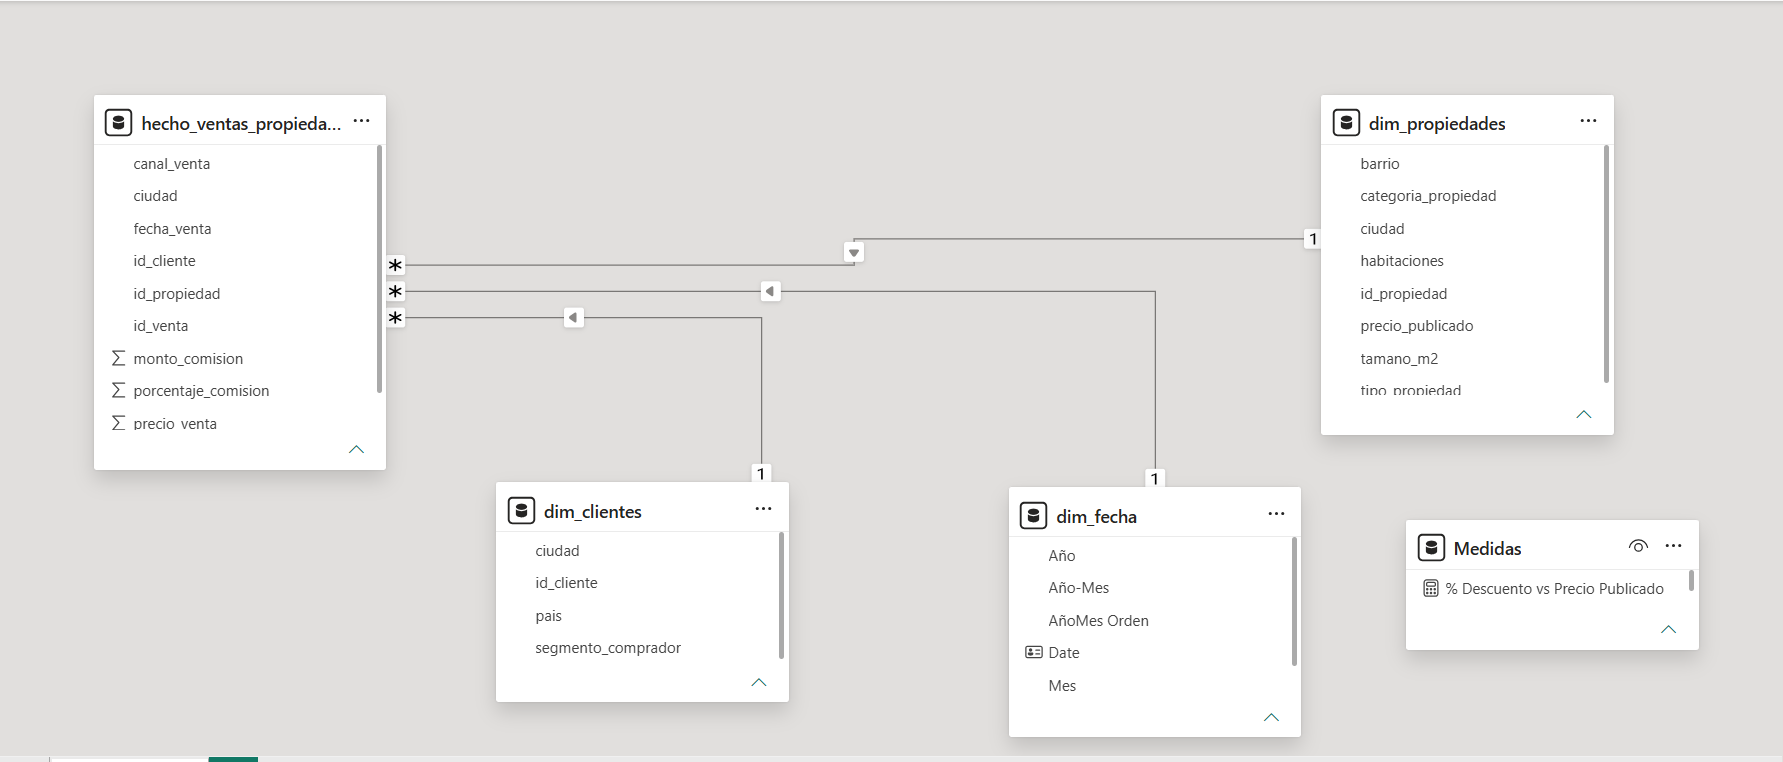


## 📊 Paso 4: Creación de medidas

En este paso deberás crear las **medidas necesarias para responder las preguntas de negocio del dashboard**.

Las medidas pueden implementarse en **Power BI (DAX)** o como **Calculated Fields en Tableau**.

---

### 4.1 🔹 Medidas base

Crear como mínimo las siguientes medidas:

- **Ingreso Total** (suma del `precio_venta`)
- **Cantidad de Ventas**
- **Ticket Promedio**
- **Comisión Total**

Estas métricas permitirán analizar el desempeño general del negocio.

---

### 4.2 🔹 Medidas con contexto de filtro

Debes crear **al menos 2 medidas** que modifiquen el contexto de filtro.

En este caso se utilizarán **medidas de participación (%)**, que permiten entender **qué proporción del ingreso total aporta cada categoría**.

Las medidas que deben construirse son:

- **Participación de ingresos por tipo de propiedad**
- **Participación de ingresos por canal de venta**
- **Participación de ingresos por segmento de cliente**

Para ello:
- Modifica el contexto de filtro con las funciones propias de cada herramienta
  - En Power BI, usa `CALCULATE`
  - En Tableau, usa expresiones como `FIXED` (LOD)

Elimina el filtro de la dimensión correspondiente para obtener el total

Asegúrate de que el denominador represente el total sin el filtro de la categoría, mientras que el numerador sí lo conserva.

Estas medidas se utilizarán principalmente como **tooltip o etiqueta adicional en los gráficos** del dashboard para complementar el análisis.

---

### 4.3 🔹 Inteligencia de tiempo

Utilizando la tabla **`dim_fecha`** (Power BI) o las funciones de fecha en Tableau, debes crear al menos 2 de las siguientes medidas:

- **Ventas Year to Date (YTD)**
- **Ventas Month to Date (MTD)**
- **Ventas del año anterior**
- **Crecimiento Year over Year (YoY)**

Estas métricas permitirán analizar la evolución del negocio en el tiempo.

---

### 4.4 🔹 Medidas para análisis de cohortes

Debes crear cálculos que permitan analizar **si los clientes vuelven a comprar después de su primera compra**.

⚠️ Estos cálculos deben crearse como **columnas calculadas**, no como medidas.  
Todas deben crearse en la tabla **`hecho_ventas_propiedades`**.

Debes crear como mínimo:

- **Primera compra por cliente** → fecha mínima de compra de cada cliente.
- **Mes Cohorte** → mes en que el cliente realizó su **primera compra** (mes de adquisición).
- **Mes Venta** → mes en que ocurre cada transacción. Este campo permite identificar **cuándo el cliente vuelve a comprar** después de su primera compra.

Estos cálculos permitirán construir una **matriz de cohortes** donde:

- **Filas** representen el **mes de cohorte**
- **Columnas** representen el **mes de venta**
- **Valores** muestren **cantidad de ventas o ingresos**

---

## 📊 Paso 5: Estructura del reporte

El dashboard debe contener **mínimo tres páginas**.

---

### 5.1 1️⃣ Overview Ejecutivo

Debe mostrar **el desempeño general del negocio**.

Incluir minimo 4 KPIs:

- **KPIs principales**  
  - Ingreso Total  
  - Cantidad de Ventas  
  - Ticket Promedio  
  - Comisión Total  

- **Tendencia de ventas en el tiempo**

- **Ingresos o ventas por ciudad**

- **Crecimiento Year over Year (YoY)**

---

### 5.2 2️⃣ Análisis Comercial

Debe analizar **qué productos, canales y clientes generan más ingresos**.

Incluir:

- **Ingreso por tipo de propiedad**
- **Ventas o ingresos por canal de venta**
- **Ventas o ingresos por segmento de cliente**
- **Tabla con formato condicional (colores semáforo)**  
  Sugerencia de campos:
  - tipo_propiedad
  - Ingreso Total
  - Cantidad Ventas
  - Ticket Promedio  
  Aplicar **formato condicional** para resaltar las categorías con mayor desempeño.

Se recomienda usar **tooltips con medidas de participación (%)**.

---

### 5.3 3️⃣ Análisis de Cohortes

Debe analizar **recurrencia de clientes**.

Incluir:

- **Matriz de cohortes**
  - Filas → Mes Cohorte
  - Columnas → Mes Venta
  - Valores → Cantidad Ventas o Ingreso Total

Esto permitirá observar **si los clientes vuelven a comprar y comparar cohortes en el tiempo**.


## 📈 Paso 6: Resumen ejecutivo"
## Hallazgos clave

- El ingreso total del periodo fue de $6,012,502,170, generado a través de 8,500 ventas.
- El tipo de propiedad que genera mayor revenue es Casa, con aproximadamente $2.24 mil millones en ingresos.
- Bogotá es la ciudad con mayor volumen de ventas, con aproximadamente 4.4 mil operaciones, frente a 4.1 mil de Ciudad de México.
- El canal de venta con mayor participación en los ingresos es Corredor, concentrando aproximadamente 72.8% del revenue total.

## Métricas principales

- Ingreso Total: $6,012,502,170
- Cantidad de Ventas: 8,500
- Ticket Promedio: $707,353
- Comisión Total: aproximadamente $201 millones

## Insights accionables

- El segmento de compradores Primera vez concentra aproximadamente 62.9% del ingreso total, convirtiéndose en el principal segmento comercial del negocio.
- Las propiedades tipo Casa generan el mayor ingreso, mientras que Departamento concentra el mayor volumen de operaciones, mostrando diferencias entre volumen de ventas y generación de revenue.
- El canal Corredor concentra aproximadamente 72.8% de los ingresos, evidenciando una fuerte dependencia de este canal para la generación de revenue.
- El análisis de cohortes muestra una retención cercana al 9% en M1, M3 y M6, lo que evidencia una oportunidad para fortalecer la recurrencia y recompra de clientes.

## Recomendaciones estratégicas

- Priorizar la comercialización de propiedades tipo Casa debido a su mayor contribución al ingreso total, manteniendo a Departamento como una categoría relevante para sostener el volumen de operaciones.
- Fortalecer el canal Corredor, dado que representa el principal generador de ingresos, y evaluar oportunidades para incrementar la participación del canal Directo.
- Desarrollar estrategias específicas para el segmento Primera vez, buscando convertir compradores iniciales en clientes recurrentes.
- Implementar estrategias de retención y recompra, especialmente durante los primeros meses posteriores a la adquisición.
- Analizar las cohortes con mejor comportamiento de recurrencia para identificar patrones que puedan replicarse en futuras estrategias comerciales.

## Conclusión ejecutiva

El análisis muestra un negocio con $6.01 mil millones en ingresos y 8,500 ventas, cuya generación de revenue se concentra principalmente en las propiedades tipo Casa, el segmento Primera vez y el canal Corredor. Bogotá lidera el volumen de operaciones, mientras que el análisis de cohortes evidencia una oportunidad relevante para incrementar la recurrencia de los clientes.

La estrategia comercial debería enfocarse en proteger las principales fuentes de ingreso y, simultáneamente, fortalecer la retención, recompra y diversificación de canales.